# SITUACIÓN 2

In [1]:
import sys
print(sys.executable)

c:\Users\Samuel\Desktop\SITUACION2\venv\Scripts\python.exe


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix
)
from sklearn.neighbors import NearestNeighbors

In [3]:
DATASET_PATH = "data/EuroSAT_RGB"
print(os.listdir(DATASET_PATH))

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Bloque 1

### Usamos solo los primeros 10000 ya que es muy grande el dataset

hacer entrenamiento con gpu

In [ ]:
features = []
labels = []

def extract_features(image):
    image = cv2.resize(image, (64, 64))
    
    mean = image.mean(axis=(0,1))
    std = image.std(axis=(0,1))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    texture = gray.std()
    
    return np.hstack([mean, std, texture])

max_images = 10000
count = 0

for label in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, label)
    
    for file in os.listdir(class_path):
        if count >= max_images:
            break
            
        img_path = os.path.join(class_path, file)
        image = cv2.imread(img_path)
        
        if image is not None:
            feat = extract_features(image)
            features.append(feat)
            labels.append(label)
            count += 1
            
    if count >= max_images:
        break

X = np.array(features)
y = np.array(labels)

print("Shape del dataset:", X.shape)

Shape del dataset: (10000, 7)


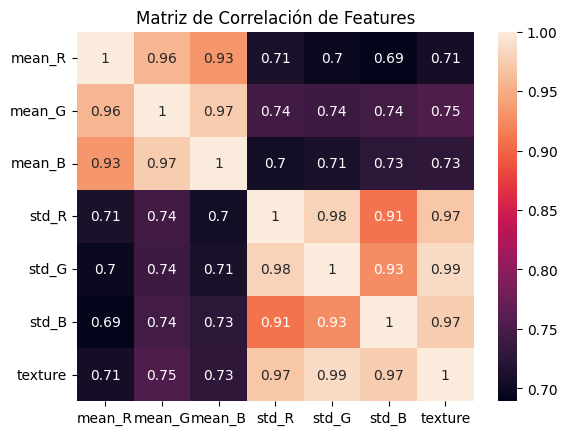

In [27]:
plt.figure()
corr = pd.DataFrame(X, columns=[
    "mean_R","mean_G","mean_B",
    "std_R","std_G","std_B",
    "texture"
]).corr()

sns.heatmap(corr, annot=True)
plt.title("Matriz de Correlación de Features")
plt.show()

### Normalizamos

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Reducimos la dimension con el PCA

In [29]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_scaled)

print("Dimensión original:", X_scaled.shape)
print("Dimensión reducida:", X_reduced.shape)

Dimensión original: (10000, 7)
Dimensión reducida: (10000, 2)


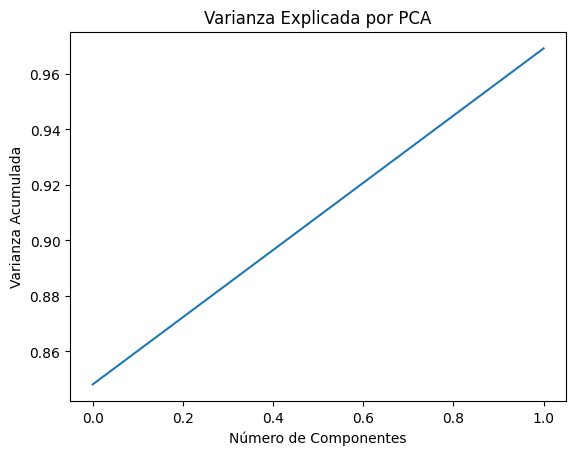

In [49]:
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Acumulada")
plt.title("Varianza Explicada por PCA")
plt.show()

El PCA permitió reducir dimensionalidad conservando el 95% de la varianza, disminuyendo redundancia entre variables altamente correlacionadas.

### Metodo del codo para kmeans

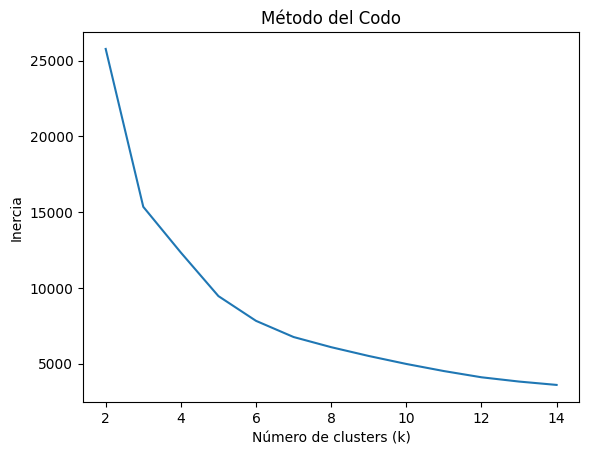

In [30]:
inertias = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_reduced)
    inertias.append(kmeans.inertia_)

plt.figure()
plt.plot(k_range, inertias)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

### Silhouette_score

In [31]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels_k)
    print(f"k={k} → Silhouette Score = {score:.4f}")

k=2 → Silhouette Score = 0.5258
k=3 → Silhouette Score = 0.4902
k=4 → Silhouette Score = 0.4475
k=5 → Silhouette Score = 0.4576
k=6 → Silhouette Score = 0.4481
k=7 → Silhouette Score = 0.4388
k=8 → Silhouette Score = 0.4359
k=9 → Silhouette Score = 0.4244
k=10 → Silhouette Score = 0.4083


Usamos k=2 porque silhouette es mayor.

Usamos k=10 también porque sabemos que hay 10 clases reales y luego evaluar ARI/NMI.

## K=2

In [32]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_2 = kmeans_2.fit_predict(X_reduced)

ari_2 = adjusted_rand_score(y, clusters_2)
nmi_2 = normalized_mutual_info_score(y, clusters_2)

print("K=2")
print("ARI:", ari_2)
print("NMI:", nmi_2)

K=2
ARI: 0.24981522645807738
NMI: 0.2756161100138285


El modelo está detectando algo como:

Grupo 1 → Vegetación (Forest, Pasture, Crops…)

Grupo 2 → Urbano / Industrial / Agua

Por eso el silhouette es alto:
Son grupos bien separados en color y textura.

Pero como hay 10 clases reales, el ARI es bajo.

## K=10


In [33]:
kmeans_10 = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters_10 = kmeans_10.fit_predict(X_reduced)

ari_10 = adjusted_rand_score(y, clusters_10)
nmi_10 = normalized_mutual_info_score(y, clusters_10)

print("K=10")
print("ARI:", ari_10)
print("NMI:", nmi_10)

K=10
ARI: 0.3846607832269537
NMI: 0.37068718355217084


Aunque el silhouette baja, el ARI y NMI suben.

Eso significa:

El modelo sí está capturando parcialmente las 10 clases reales.
Pero las features actuales (solo estadísticas RGB + textura simple) no son suficientemente ricas.


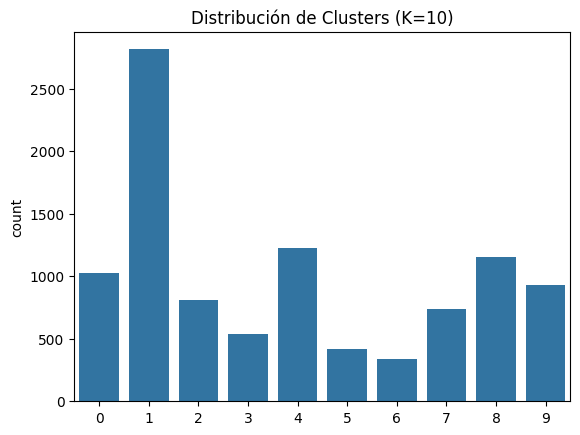

In [50]:
plt.figure()
sns.countplot(x=clusters_10)
plt.title("Distribución de Clusters (K=10)")
plt.show()

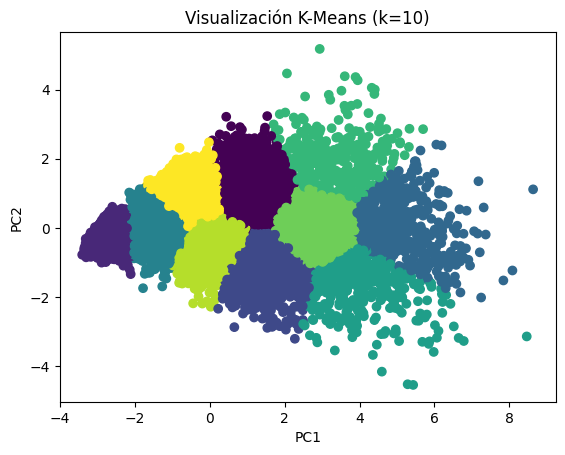

In [34]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters_10)
plt.title("Visualización K-Means (k=10)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Matríz de confusión

### DBSCAN

### Ajustar el valor de eps

In [22]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
clusters_db = dbscan.fit_predict(X_reduced)

ari_db = adjusted_rand_score(y, clusters_db)
nmi_db = normalized_mutual_info_score(y, clusters_db)

print("DBSCAN")
print("ARI:", ari_db)
print("NMI:", nmi_db)
print("Clusters encontrados:", len(set(clusters_db)))

DBSCAN
ARI: -1.1074959449071098e-05
NMI: 0.0047825339925025925
Clusters encontrados: 2


DBSCAN no logró capturar la estructura subyacente del dataset, lo que sugiere que las clases no se organizan en regiones de densidad claramente separadas bajo las características extraídas.

Encontro 2 clusters uno de vegetación y otro urbano/agua


## Cargamos las demas imagenes faltantes

In [40]:
def load_images_by_range(start, end):
    features_part = []
    labels_part = []
    
    count = 0
    
    for label in os.listdir(DATASET_PATH):
        class_path = os.path.join(DATASET_PATH, label)
        
        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)
            image = cv2.imread(img_path)
            
            if image is not None:
                if count >= start and count < end:
                    feat = extract_features(image)
                    features_part.append(feat)
                    labels_part.append(label)
                
                count += 1
                
                if count >= end:
                    break
        
        if count >= end:
            break
    
    return np.array(features_part), np.array(labels_part)

## Bloque 2 y Bloque 3

Bloque 2 (10000-20000)

Bloque 3(20000-27000)

### Procesamos lo mismo que en el primer bloque al resto de datos con esta función

In [47]:
def run_block(start, end):
    print(f"\nProcesando imágenes {start} a {end}")
    
    X_block, y_block = load_images_by_range(start, end)
    
    scaler_block = StandardScaler()
    X_scaled_block = scaler_block.fit_transform(X_block)
    
    pca_block = PCA(n_components=0.95)
    X_reduced_block = pca_block.fit_transform(X_scaled_block)
    
    print("Dimensión reducida:", X_reduced_block.shape[1])
    
    #kmeans
    kmeans_block = KMeans(n_clusters=10, random_state=42, n_init=10)
    clusters_k = kmeans_block.fit_predict(X_reduced_block)
    
    ari_k = adjusted_rand_score(y_block, clusters_k)
    nmi_k = normalized_mutual_info_score(y_block, clusters_k)
    
    print("\nK-Means")
    print("ARI:", ari_k)
    print("NMI:", nmi_k)
    
    #DBSCAN
    dbscan_block = DBSCAN(eps=0.5, min_samples=10)
    clusters_db = dbscan_block.fit_predict(X_reduced_block)
    
    ari_db = adjusted_rand_score(y_block, clusters_db)
    nmi_db = normalized_mutual_info_score(y_block, clusters_db)
    
    unique_clusters = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
    
    print("\nDBSCAN")
    print("Clusters encontrados:", unique_clusters)
    print("ARI:", ari_db)
    print("NMI:", nmi_db)

In [48]:
run_block(10000, 20000)
run_block(20000, 27000)


Procesando imágenes 10000 a 20000
Dimensión reducida: 2

K-Means
ARI: 0.19863344158401286
NMI: 0.3029248736169933

DBSCAN
Clusters encontrados: 1
ARI: -0.0004126482496763166
NMI: 0.003385420739584789

Procesando imágenes 20000 a 27000
Dimensión reducida: 2

K-Means
ARI: 0.24889753420689675
NMI: 0.36838043949763627

DBSCAN
Clusters encontrados: 5
ARI: 0.011360171818829009
NMI: 0.02728181243687897
